**HOML Chapter 14 – Pretrained Models for Transfer Learning**

This notebook demonstrates the use of pretrained models for transfer learning.

It uses a pretrained Xception model trained on ImageNet to classify 3670 pictures of flowers in 5 classes.

See also HOML page 518.

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
import numpy as np
import pandas as pd

It also requires Scikit-Learn ≥ 1.0.1:

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

And TensorFlow ≥ 2.8:

In [4]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

2025-12-14 21:19:25.924974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 21:19:25.985403: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 21:19:27.236374: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [6]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Pretrained Models for Transfer Learning

In [7]:
# import the flowers dataset from TensorFlow Datasets

import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

/home/robin/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 100%|██████████| 1/1 [00:06<00:00,  6.33s/ url]


Dataset tf_flowers downloaded and prepared to /home/robin/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


I0000 00:00:1765743579.252662    3279 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9692 MB memory:  -> device: 0, name: NVIDIA RTX A3000 12GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
# lets see how many flower pictures there are in the dataset

dataset_size

3670

In [9]:
# what are class names of the dataset

class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [10]:
# how many classes do we have

n_classes

5

In [11]:
# lets call tfds.load again and split up the data, first 10% for the test set, next 15% for validation and the remaining 75% for training

test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

2025-12-14 21:19:39.988314: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2025-12-14 21:19:40.103841: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-12-14 21:19:40.113440: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


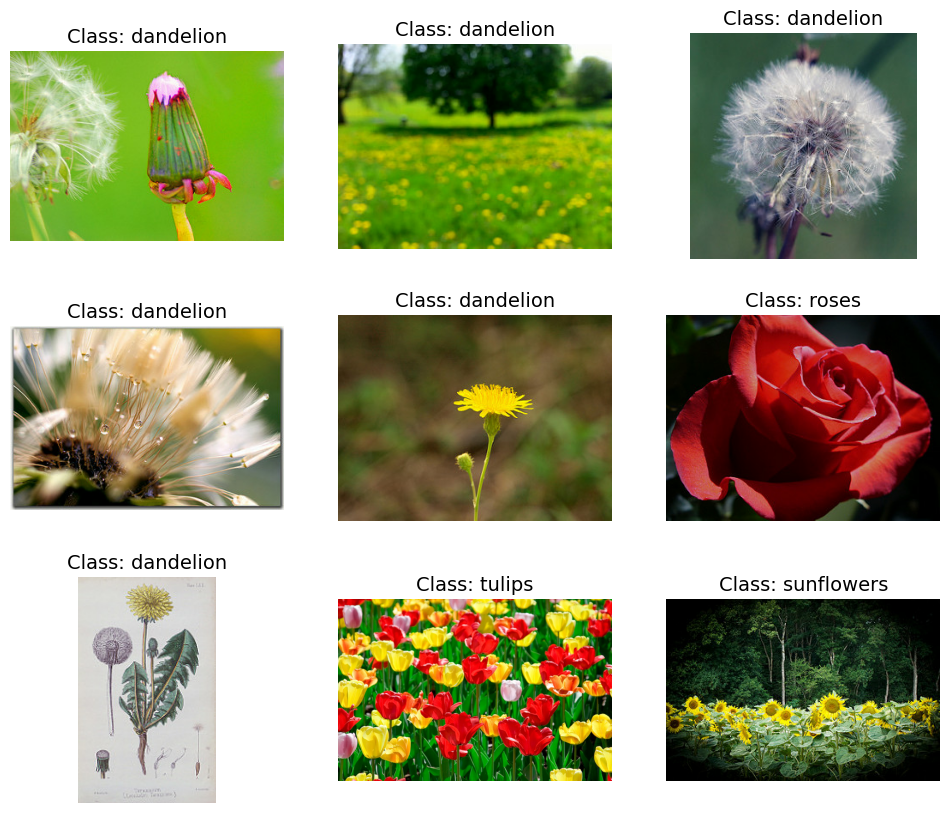

In [12]:
# extra code – displays the first 9 images in the validation set

plt.figure(figsize=(12, 10))
index = 0
for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title(f"Class: {class_names[label]}")
    plt.axis("off")

plt.show()

All three datasets contain individual images. We need to batch them, but for this we first need to ensure they all have the same size, or else batching will not work. We can use a `Resizing` layer for this. We must also call the `tf.keras.applications.xception.preprocess_input()` function to preprocess the images appropriately for the Xception model. We will also add shuffling and prefetching to the training dataset.

In [13]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter

batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

Now each batch contains 32 images, all of them 224 x 224 pixels, with pixel values ranging from -1 to 1.

Let's take a look again at the first 9 images from the validation set: they're all 224x224 now, with values ranging from -1 to 1:

2025-12-14 21:19:42.257553: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-12-14 21:19:42.372760: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


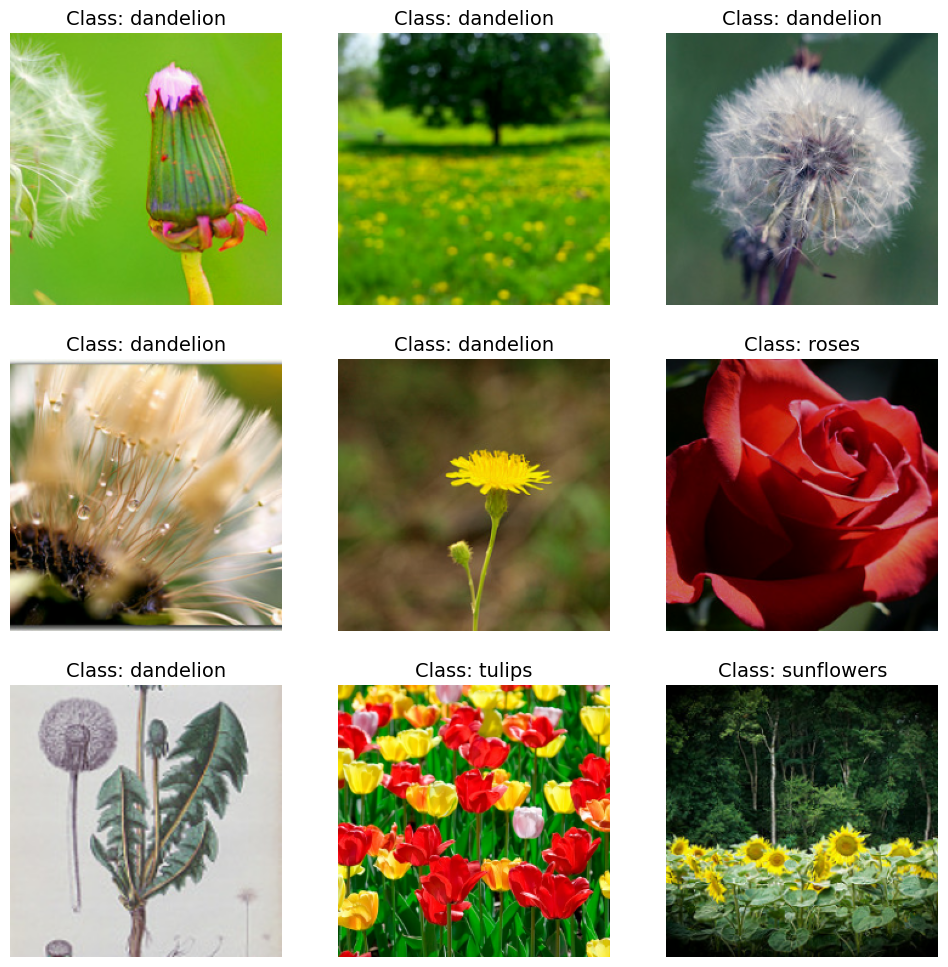

In [14]:
# extra code – displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

In [15]:
# this data augmentation model will be embedded in the final model.
# during training it will randomly flip the images horizontally, rotate them a little bit, and tweak the contrast

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

Try running the following cell multiple times to see different random data augmentations:

2025-12-14 21:19:43.166648: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


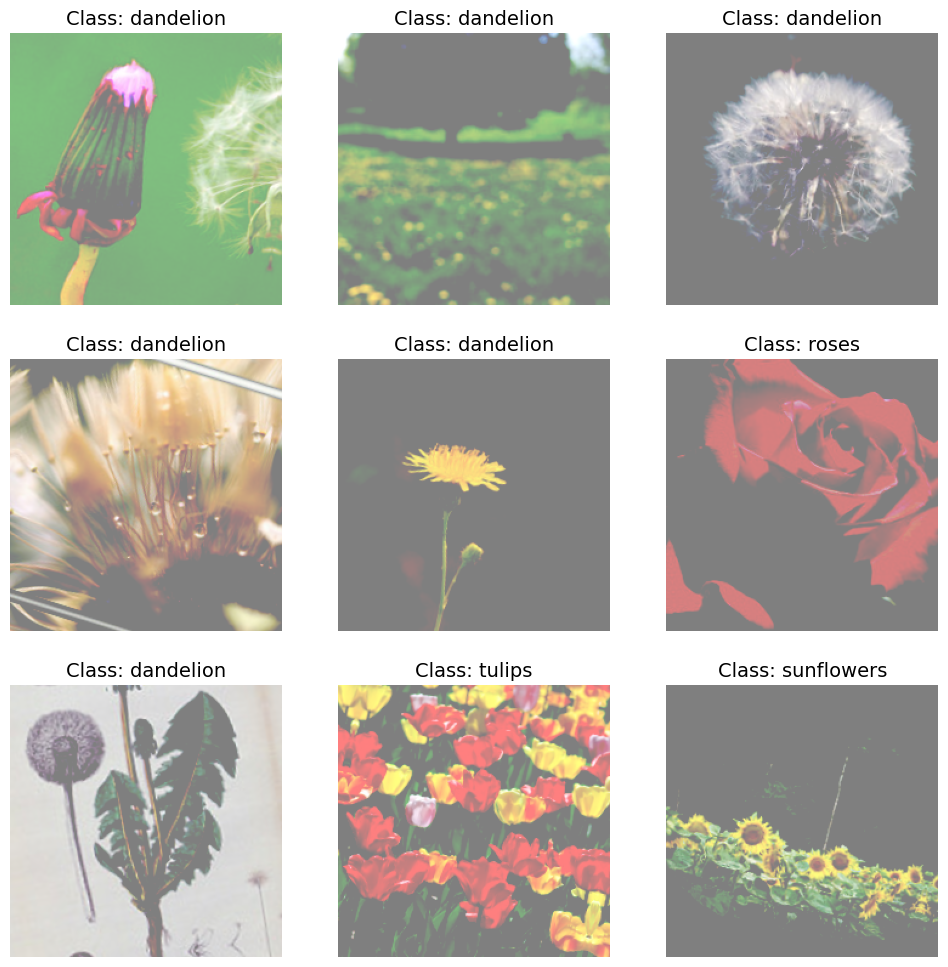

In [16]:
# extra code – displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

Now let's load the pretrained model, without its top layers (global average pooling + dense output layers), and replace them with our own, for the flower classification task:

In [17]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
# freeze the weigths of the pretrained layers (base_model) at the beginning of training

for layer in base_model.layers:
    layer.trainable = False

Let's train the model for a few epochs, while keeping the base model weights fixed:

In [19]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3


2025-12-14 21:19:52.090929: I external/local_xla/xla/service/service.cc:163] XLA service 0x57ac1ab4ff20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-14 21:19:52.090998: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A3000 12GB Laptop GPU, Compute Capability 8.6
2025-12-14 21:19:52.169951: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-14 21:19:52.849173: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2025-12-14 21:20:03.951724: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-14 21:20:04.297356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel ti

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6873 - loss: 1.0919

2025-12-14 21:20:40.191206: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-14 21:20:40.441054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-14 21:20:41.280035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-14 21:20:41.531535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-14 21:20:41.799545: E external/local_xla/xla/stream_

86/86 ━━━━━━━━━━━━━━━━━━━━ 65s 410ms/step - accuracy: 0.8012 - loss: 0.8368 - val_accuracy: 0.8294 - val_loss: 0.6876
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.9077 - loss: 0.3333 - val_accuracy: 0.8675 - val_loss: 0.6034
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9350 - loss: 0.2096 - val_accuracy: 0.8748 - val_loss: 0.5862


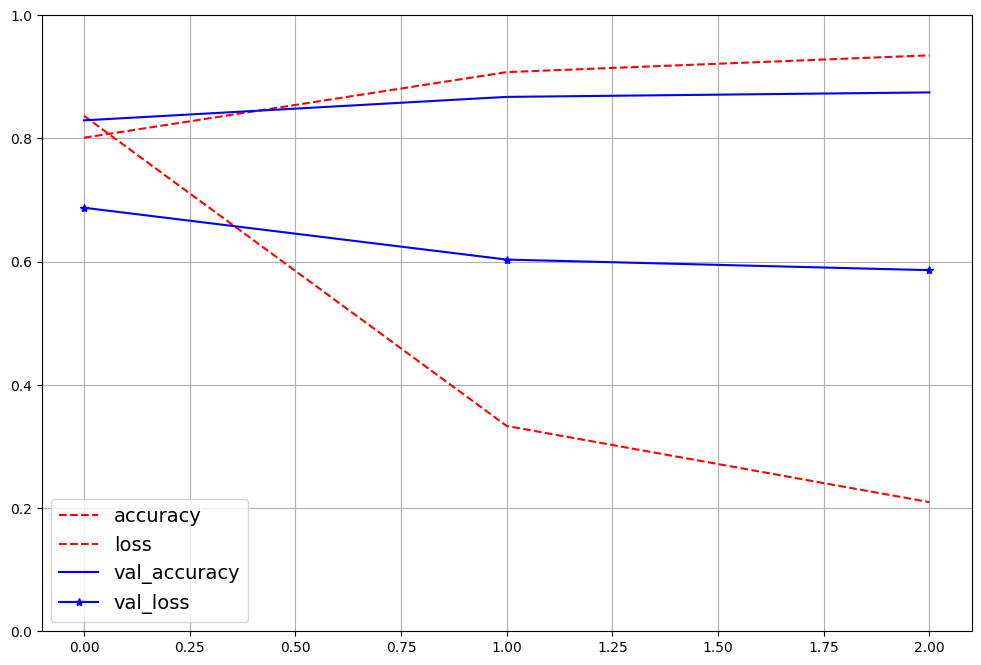

In [20]:
# Lets check if the validation accuracy reaches more than 80%
# If so, we can start to unfreeze some of the base models top layers and train again

pd.DataFrame(history.history).plot(figsize=(12, 8), style=['r--','r--','b-','b-*'])
plt.grid(True)
plt.gca().set_ylim(0, 1) #set y-axis limits
plt.show()

In [21]:
# lets make a list of the base model layer names

for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end="")
    print()

  0: input_layer_2          33: block4_pool            66: block8_sepconv1_act    99: block11_sepconv2_act  
  1: block1_conv1           34: batch_normalization_2  67: block8_sepconv1       100: block11_sepconv2      
  2: block1_conv1_bn        35: add_2                  68: block8_sepconv1_bn    101: block11_sepconv2_bn   
  3: block1_conv1_act       36: block5_sepconv1_act    69: block8_sepconv2_act   102: block11_sepconv3_act  
  4: block1_conv2           37: block5_sepconv1        70: block8_sepconv2       103: block11_sepconv3      
  5: block1_conv2_bn        38: block5_sepconv1_bn     71: block8_sepconv2_bn    104: block11_sepconv3_bn   
  6: block1_conv2_act       39: block5_sepconv2_act    72: block8_sepconv3_act   105: add_9                 
  7: block2_sepconv1        40: block5_sepconv2        73: block8_sepconv3       106: block12_sepconv1_act  
  8: block2_sepconv1_bn     41: block5_sepconv2_bn     74: block8_sepconv3_bn    107: block12_sepconv1      
  9: block2_sepconv

Now that the weights of our new top layers are not too bad, we can make the top part of the base model trainable again, and continue training, but with a lower learning rate:

In [22]:
# unfreeze starting from layer 56 of the base model

for layer in base_model.layers[56:]:
    layer.trainable = True

# lower the learning rate

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

# build the model

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# train the model with 10 epochs

history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10


2025-12-14 21:21:24.105159: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-14 21:21:24.344899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-14 21:21:24.589306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


86/86 ━━━━━━━━━━━━━━━━━━━━ 51s 311ms/step - accuracy: 0.9070 - loss: 0.2851 - val_accuracy: 0.8621 - val_loss: 0.7136
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.9797 - loss: 0.0635 - val_accuracy: 0.8984 - val_loss: 0.3219
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.9978 - loss: 0.0110 - val_accuracy: 0.9129 - val_loss: 0.2683
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.9971 - loss: 0.0091 - val_accuracy: 0.9038 - val_loss: 0.3215
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.9971 - loss: 0.0059 - val_accuracy: 0.9111 - val_loss: 0.3106
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9074 - val_loss: 0.3170
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy: 0.9978 - loss: 0.0087 - val_accuracy: 0.9111 - val_loss: 0.3217
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.918

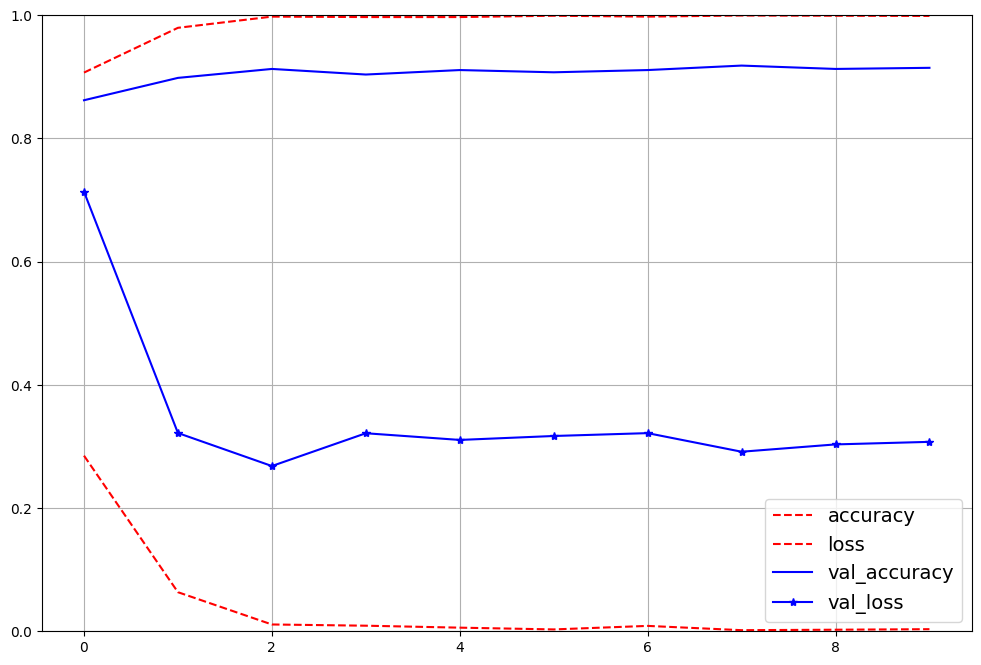

In [23]:
# Lets see if the validation accuracy has improved after unfreezing top layers of the base model

pd.DataFrame(history.history).plot(figsize=(12, 8), style=['r--','r--','b-','b-*'])
plt.grid(True)
plt.gca().set_ylim(0, 1) #set y-axis limits
plt.show()

In [24]:
# lets unfreeze some more
# unfreeze starting from layer 36 of the base model

for layer in base_model.layers[36:]:
    layer.trainable = True

# lower the learning rate

optimizer = tf.keras.optimizers.SGD(learning_rate=0.005, momentum=0.9)

# build the model

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# train the model with 10 epochs

history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 52s 345ms/step - accuracy: 0.9985 - loss: 0.0077 - val_accuracy: 0.9074 - val_loss: 0.3122
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 186ms/step - accuracy: 0.9978 - loss: 0.0042 - val_accuracy: 0.9056 - val_loss: 0.3394
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 195ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 0.9056 - val_loss: 0.3335
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 205ms/step - accuracy: 0.9993 - loss: 0.0021 - val_accuracy: 0.9165 - val_loss: 0.3275
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.9989 - loss: 0.0022 - val_accuracy: 0.9201 - val_loss: 0.3236
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 185ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9220 - val_loss: 0.3142
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 230ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.9220 - val_loss: 0.3120
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 189ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accu

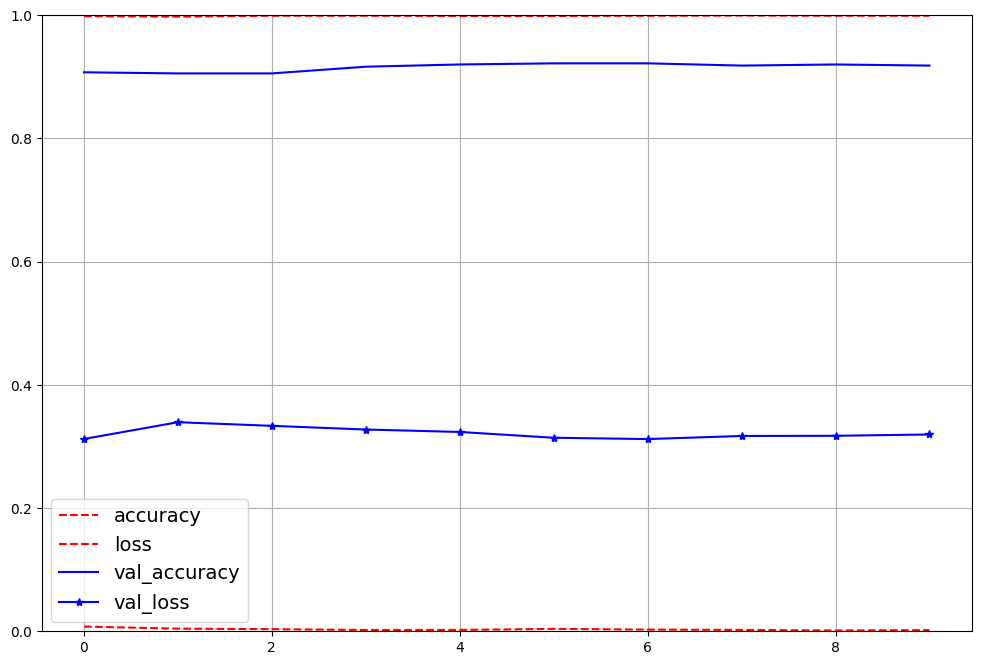

In [25]:
# Lets see if the validation accuracy has improved after unfreezing top layers of the base model

pd.DataFrame(history.history).plot(figsize=(12, 8), style=['r--','r--','b-','b-*'])
plt.grid(True)
plt.gca().set_ylim(0, 1) #set y-axis limits
plt.show()

In [26]:
# Evaluate on the test set

model.evaluate(test_set)

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.9309 - loss: 0.2476

2025-12-14 21:28:18.195642: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[15,256,55,55]{3,2,1,0}, u8[0]{0}) custom-call(f32[15,256,55,55]{3,2,1,0}, f32[256,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=256, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-12-14 21:28:18.224625: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.029244137s
Trying algorithm eng3{k11=2} for conv (f32[15,256,55,55]{3,2,1,0}, u8[0]{0}) custom-call(f32[15,256,55,55]{3,2,1,0}, f32[256,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=256, custom_call_target="__cudnn

12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9373 - loss: 0.2303 


[0.23032796382904053, 0.9373297095298767]